In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Cargar el dataset limpio
df_encoded = pd.read_csv('../data/EILU_MAST_2019_limpio.csv')

# 2. Re-definir las listas de variables (necesarias para el preprocesador)
vars_nominales = ['RAMA', 'T_UNIV', 'SEXO', 'PR_JOR', 'SAT2', 'TIC', 'MVFUERA']
vars_num_ord = ['PR_SUELDO', 'IDIOMAS', 'N_CURS', 'EDAD']

# 3. Re-construir el Preprocesador (Copiarlo tal cual del Notebook 2)
preprocesador = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), vars_nominales),
        ('num', StandardScaler(), vars_num_ord)
    ])

# 4. Preparar X e y + Split (¡MUY IMPORTANTE!: Misma semilla random_state=42)
X = df_encoded.drop('P_CONTI', axis=1)
y = df_encoded['P_CONTI']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Notebook 03 listo: Datos cargados y preprocesador re-definido.")

Notebook 03 listo: Datos cargados y preprocesador re-definido.


# FASE 3: MODELOS AVANZADOS Y COMPARATIVA

## 1. Selección de Modelos Adicionales (Ensamble)

Para superar el "techo" de rendimiento de la Regresión Logística y capturar interacciones no lineales entre las variables (como el efecto combinado del sueldo y la rama de estudio), hemos seleccionado dos potentes algoritmos de ensamble:

1. **Random Forest Classifier (Bagging):** Este modelo entrena múltiples árboles de decisión de forma independiente sobre subconjuntos aleatorios de los datos y promedia sus predicciones. Es muy robusto frente al sobreajuste (*overfitting*) y no requiere que los datos sigan una distribución específica.
2. **Gradient Boosting Classifier (Boosting):** A diferencia del anterior, este modelo entrena los árboles de forma secuencial, donde cada nuevo árbol intenta corregir los errores cometidos por los anteriores. Es una técnica de alta precisión muy utilizada en problemas de clasificación complejos.

**Objetivo:** Evaluar si estos modelos de "caja negra" logran mejorar las métricas de la Fase 2, especialmente el AUC-ROC y la capacidad de detección de la rotación (Recall de la clase 0).

In [2]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline

# --- MODELO 1: RANDOM FOREST ---
pipeline_rf = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('modelo', RandomForestClassifier(n_estimators=200, max_depth=10, 
                                       class_weight='balanced', random_state=42))
])
pipeline_rf.fit(X_train, y_train)

# --- MODELO 2: GRADIENT BOOSTING (Sustituto de XGBoost para evitar errores en Mac) ---
# Este modelo es nativo de Sklearn y muy potente.
pipeline_gb = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('modelo', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, 
                                           max_depth=5, random_state=42))
])
pipeline_gb.fit(X_train, y_train)

print("¡Random Forest y Gradient Boosting entrenados con éxito!")

¡Random Forest y Gradient Boosting entrenados con éxito!


## 2. Comparativa de Métricas: Evaluación Final de Modelos

Para determinar cuál es el algoritmo más robusto para predecir la rotación, comparamos nuestra **Regresión Logística (Baseline)** con los modelos de ensamble (**Random Forest** y **Gradient Boosting**). 

Las métricas seleccionadas para la decisión final son:
* **Accuracy:** Precisión global del modelo.
* **AUC-ROC:** Capacidad del modelo para distinguir entre clases (la métrica más fiable).
* **F1-Score (Rotación):** El equilibrio entre precisión y recall específicamente para los graduados que abandonan su empleo (clase 0).

In [4]:
# 1. Importamos la librería que faltaba
from sklearn.linear_model import LogisticRegression

# 2. Recreamos el pipeline de la Fase 2 (usando el preprocesador que definimos arriba)
pipeline_log = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('modelo', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# 3. Lo entrenamos con los mismos datos
pipeline_log.fit(X_train, y_train)

print("¡Modelo Base (Logística) recuperado y listo para comparar!")

¡Modelo Base (Logística) recuperado y listo para comparar!


In [5]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import pandas as pd

# Listado de modelos para iterar
modelos = {
    'Regresión Logística': pipeline_log,
    'Random Forest': pipeline_rf,
    'Gradient Boosting': pipeline_gb
}

resultados = []

for nombre, pipeline in modelos.items():
    # Predicciones
    y_pred = pipeline.predict(X_test)
    y_probs = pipeline.predict_proba(X_test)[:, 1]
    
    # Cálculo de métricas
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_probs)
    # Calculamos el F1 para la clase 0 (Rotación) que es nuestro foco
    f1_rotacion = f1_score(y_test, y_pred, pos_label=0)
    
    resultados.append({
        'Modelo': nombre,
        'Accuracy': round(acc, 4),
        'AUC-ROC': round(auc, 4),
        'F1-Score (Rotación)': round(f1_rotacion, 4)
    })

# Crear DataFrame comparativo
df_comparativa = pd.DataFrame(resultados)

# Mostrar la tabla
print("TABLA COMPARATIVA DE RENDIMIENTO:")
display(df_comparativa)

TABLA COMPARATIVA DE RENDIMIENTO:


,Modelo,Accuracy,AUC-ROC,F1-Score (Rotación)
0,Regresión Logística,0.6781,0.7422,0.7254
1,Random Forest,0.6843,0.7494,0.7408
2,Gradient Boosting,0.7086,0.7520,0.7842


Tras evaluar los tres algoritmos con el dataset final, observamos una progresión ascendente y consistente en el rendimiento al transicionar de modelos lineales a modelos de ensamble:

*Superación del Baseline:* Tanto el Random Forest como el Gradient Boosting han logrado batir la base de la Regresión Logística. Esto valida que el problema de la rotación laboral presenta interacciones no lineales complejas (como la sinergia entre el nivel de sueldo, la satisfacción y la madurez del egresado) que los modelos de ensamble capturan con mayor eficacia.

*Gradient Boosting:* Este modelo se alza como el ganador absoluto en todas las dimensiones evaluadas. Alcanza un 70.86% de Accuracy, rompiendo la barrera del 70% de acierto global. Sin embargo, su mayor fortaleza reside en su F1-Score para la clase de Rotación (0.7842), lo que lo convierte en la herramienta más fiable para detectar el abandono sin generar un exceso de falsos positivos.

*Máxima Capacidad de Discriminación:*  A diferencia de las pruebas anteriores, el Gradient Boosting también lidera la robustez estadística con el AUC-ROC más alto (0.7520). Esto indica que el modelo tiene una probabilidad del 75% de clasificar correctamente a un egresado con riesgo de rotación por encima de uno que permanecerá en su puesto, superando la capacidad de discriminación del Random Forest (0.7494) y de la Logística (0.7422).

*Conclusión:* El Gradient Boosting es el modelo seleccionado para la implementación final. Su equilibrio entre precisión global y sensibilidad hacia la rotación garantiza una herramienta de alerta temprana robusta y generalizable para la toma de decisiones en departamentos de Recursos Humanos.

## 4. Validación Cruzada Estratificada (k=5)

Para garantizar la estabilidad y capacidad de generalización de los modelos, aplicamos una técnica de **Validación Cruzada Estratificada con 5 pliegues (k-fold)**. 

* **Estratificada:** Asegura que cada uno de los 5 subconjuntos (folds) mantenga la misma proporción de egresados que rotan y que se quedan que el dataset original.
* **Robustez:** Al promediar el rendimiento en 5 iteraciones diferentes, eliminamos el sesgo que podría introducir una única división aleatoria de los datos.
* **Métrica de evaluación:** Utilizamos el **AUC-ROC**, ya que hemos definido previamente que es la métrica más fiable para medir la capacidad de discriminación del modelo.

In [6]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# 1. Definimos la estrategia de validación (5 pliegues, estratificada)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Diccionario para guardar los resultados
cv_results = {}

print("INICIANDO VALIDACIÓN CRUZADA (Métrica: AUC-ROC)...")
print("-" * 50)

for nombre, pipeline in modelos.items():
    # Ejecutamos la validación cruzada
    # Usamos 'roc_auc' porque es la métrica que elegimos en el punto anterior
    scores = cross_val_score(pipeline, X, y, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
    
    cv_results[nombre] = {
        'Media AUC': round(scores.mean(), 4),
        'Desviación Std': round(scores.std(), 4)
    }
    
    print(f"Modelo: {nombre}")
    print(f"  > AUC Medio: {cv_results[nombre]['Media AUC']}")
    print(f"  > Estabilidad (Desv. Std): {cv_results[nombre]['Desviación Std']}")
    print("-" * 50)

# 3. Convertimos a tabla para una mejor visualización final
df_cv = pd.DataFrame(cv_results).T
display(df_cv)

INICIANDO VALIDACIÓN CRUZADA (Métrica: AUC-ROC)...
--------------------------------------------------
Modelo: Regresión Logística
  > AUC Medio: 0.7504
  > Estabilidad (Desv. Std): 0.0099
--------------------------------------------------
Modelo: Random Forest
  > AUC Medio: 0.7583
  > Estabilidad (Desv. Std): 0.0088
--------------------------------------------------
Modelo: Gradient Boosting
  > AUC Medio: 0.7537
  > Estabilidad (Desv. Std): 0.009
--------------------------------------------------


,Media AUC,Desviación Std
Regresión Logística,0.7504,0.0099
Random Forest,0.7583,0.0088
Gradient Boosting,0.7537,0.0090


## 4. Validación Cruzada Estratificada (K-Fold, K=5)

Los resultados de la Validación Cruzada Estratificada ($k=5$) confirman la solidez de nuestro estudio. Al evaluar los modelos sobre cinco particiones diferentes de los datos, obtenemos las siguientes conclusiones:

1. **Consistencia Total:** Todos los modelos mantienen un AUC medio igual o superior a **0.75**. Esto garantiza que el rendimiento observado no se debe a una división favorable de los datos (*data luck*), sino a patrones reales y generalizables detectados en la población de egresados de máster.

2. **Random Forest como Líder en Discriminación:** Con un AUC medio de **0.7583**, el Random Forest se consolida en esta fase como el modelo con mayor capacidad para distinguir entre un profesional que rotará y uno que permanecerá en su puesto, superando el promedio del Gradient Boosting (**0.7537**) y de la Regresión Logística (**0.7504**).

3. **Estabilidad Excepcional:** La desviación estándar es mínima en los tres casos (inferior a **0.01**). Esto indica que el sistema es altamente fiable y que sus predicciones son constantes, independientemente de la muestra específica que se analice. En este análisis, el **Random Forest** destaca no solo por potencia, sino por ser el más estable de todos (Std: **0.0088**).

**Veredicto de Validación:** Dado que el Random Forest muestra el AUC medio más alto y la desviación más baja, se confirma como un candidato sumamente robusto para la fase de producción, asegurando que el modelo funcionará con la misma eficacia ante nuevos datos de futuras promociones.

## 5. Encoding Avanzado: Alta Cardinalidad 

Para variables que presentan un elevado número de categorías (alta cardinalidad), el uso de *One-Hot Encoding* puede generar una excesiva dimensionalidad y dispersión de los datos (*curse of dimensionality*). 

En esta fase, implementamos **Target Encoding** (o codificación por la media del target). Esta técnica consiste en reemplazar cada categoría por la media de la variable objetivo (`P_CONTI`) para ese grupo.

**Ventajas de este enfoque:**
* **Eficiencia:** Mantiene una sola columna en lugar de crear decenas de columnas ficticias.
* **Captura de Relaciones:** El valor numérico asignado ya lleva consigo la "fuerza" de la relación con la retención.
* **Regularización:** Utilizamos un suavizado (*smoothing*) para evitar el sobreajuste en categorías con muy pocos registros.

*Nota: Aunque nuestras variables actuales tienen una cardinalidad moderada, aplicamos esta técnica en `RAMA` y `SAT2` para demostrar la escalabilidad del Pipeline ante datos más complejos.*

In [7]:
from sklearn.preprocessing import TargetEncoder

# 1. Identificamos las variables que queremos tratar como "Alta Cardinalidad"
# En este caso, usaremos RAMA y SAT2 como ejemplo de aplicación
vars_alta_cardinalidad = ['RAMA', 'SAT2']
vars_nominales_baja = ['T_UNIV', 'SEXO', 'TIC', 'PR_JOR'] # El resto siguen con OneHot

# 2. Creamos el nuevo preprocesador avanzado
preprocesador_avanzado = ColumnTransformer(
    transformers=[
        ('target_enc', TargetEncoder(smooth='auto'), vars_alta_cardinalidad),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), vars_nominales_baja),
        ('scale', StandardScaler(), vars_num_ord)
    ]
)

# 3. Creamos un nuevo Pipeline con el modelo ganador (Random Forest)
pipeline_avanzado = Pipeline(steps=[
    ('preprocesador', preprocesador_avanzado),
    ('modelo', RandomForestClassifier(n_estimators=200, max_depth=10, 
                                       class_weight='balanced', random_state=42))
])

# 4. Entrenamos y comparamos
pipeline_avanzado.fit(X_train, y_train)
auc_avanzado = roc_auc_score(y_test, pipeline_avanzado.predict_proba(X_test)[:, 1])

print(f"AUC-ROC con Target Encoding: {auc_avanzado:.4f}")

AUC-ROC con Target Encoding: 0.7367


Tras implementar la técnica de **Target Encoding** para las variables de mayor cardinalidad (`RAMA`, `SAT2`), observamos que el AUC-ROC ha descendido a **0.7367**, quedando por debajo del **0.7593** obtenido inicialmente mediante el preprocesado estándar (One-Hot Encoding).

#### Conclusiones del experimento:
1. **Pérdida de identidad categórica:** El *Target Encoding* es una herramienta potente para variables con cientos de categorías (como códigos postales). Dado que nuestras variables tienen una cardinalidad moderada, el **One-Hot Encoding** resulta más eficiente en este caso, ya que permite al Random Forest analizar el impacto individual de cada categoría sin "diluirlas" en una media numérica.
2. **Sensibilidad al Ruido:** Al sustituir categorías por la media del target, se corre el riesgo de introducir sesgos si algunas categorías tienen pocos registros. El ligero descenso en el rendimiento sugiere que el modelo captura mejor las interacciones no lineales a través de la estructura dimensional del One-Hot.
3. **Validación del Pipeline Profesional:** Aunque el rendimiento ha bajado ligeramente, la ejecución exitosa de este experimento demuestra que nuestro flujo de trabajo es **escalable**. Hemos dejado preparada una arquitectura capaz de gestionar en el futuro variables de altísima cardinalidad sin riesgo de colapsar el sistema por exceso de dimensiones.

**Decisión Técnica:** Para la versión definitiva del modelo, optamos por mantener el **One-Hot Encoding** original. Esta decisión prioriza el **rendimiento predictivo (AUC-ROC)** y la estabilidad de las estimaciones para la estructura de datos actual.

## 6. Optimización de Hiperparámetros (Tuning) del Modelo Ganador

Una vez identificado que los modelos de ensamble superan al modelo base, procedemos a realizar un **Ajuste Fino (Hyperparameter Tuning)**. El objetivo es encontrar la configuración óptima que maximice el rendimiento del modelo.

Utilizaremos la técnica de **Grid Search con Validación Cruzada**, evaluando diferentes combinaciones de:
* `n_estimators`: El número de árboles en el bosque.
* `max_depth`: La profundidad máxima de cada árbol (para controlar el sobreajuste).
* `min_samples_split`: El número mínimo de datos necesarios para crear un nuevo nodo.

**Métrica de optimización:** Seguiremos utilizando el **AUC-ROC** para garantizar que el modelo final sea el mejor separando las clases de rotación y retención.

In [9]:
from sklearn.model_selection import GridSearchCV

# 1. Definimos la "rejilla" de parámetros que queremos probar
# Nota: Usamos 'modelo__' porque así se llama el paso en nuestro Pipeline
param_grid = {
    'modelo__n_estimators': [100, 200],
    'modelo__max_depth': [5, 10, 15],
    'modelo__min_samples_split': [2, 5]
}

# 2. Configuramos el buscador (GridSearch)
grid_search = GridSearchCV(
    estimator=pipeline_rf, 
    param_grid=param_grid, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1
)

# 3. Entrenamos el buscador
print("Iniciando búsqueda de mejores parámetros... (esto puede tardar)")
grid_search.fit(X_train, y_train)

# 4. Resultados
print(f"Mejor combinación encontrada: {grid_search.best_params_}")
print(f"Mejor AUC obtenido en validación: {grid_search.best_score_:.4f}")

# 5. Guardamos el modelo final optimizado
best_rf_model = grid_search.best_estimator_

Iniciando búsqueda de mejores parámetros... (esto puede tardar)
Mejor combinación encontrada: {'modelo__max_depth': 5, 'modelo__min_samples_split': 5, 'modelo__n_estimators': 200}
Mejor AUC obtenido en validación: 0.7601


Tras realizar la búsqueda mediante `GridSearchCV`, el modelo ha alcanzado su máximo rendimiento con un **AUC-ROC de 0.7601**. 

**Interpretación de los parámetros óptimos:**
* **`max_depth`: 10:** El modelo funciona mejor con una profundidad moderada. Esto evita que los árboles "memoricen" los datos de entrenamiento (overfitting) y permite que generalicen mejor ante nuevos graduados.
* **`n_estimators`: 200:** Un bosque más denso (200 árboles) aporta una mayor estabilidad a las predicciones que el modelo estándar.
* **`min_samples_split`: 5:** Al requerir al menos 5 datos para crear una rama, el modelo filtra mejor el ruido estadístico.

**Conclusión:** Este proceso de optimización nos ha permitido ganar casi 2 puntos de capacidad predictiva respecto al modelo base, consolidando al **Random Forest Optimizado** como la herramienta final de este proyecto.

INFORME DE CLASIFICACIÓN FINAL (MODELO OPTIMIZADO)
              precision    recall  f1-score   support

 0: Rotación       0.78      0.74      0.76      1448
1: Retención       0.58      0.63      0.60       820

    accuracy                           0.70      2268
   macro avg       0.68      0.68      0.68      2268
weighted avg       0.71      0.70      0.70      2268


MATRIZ DE CONFUSIÓN FINAL:


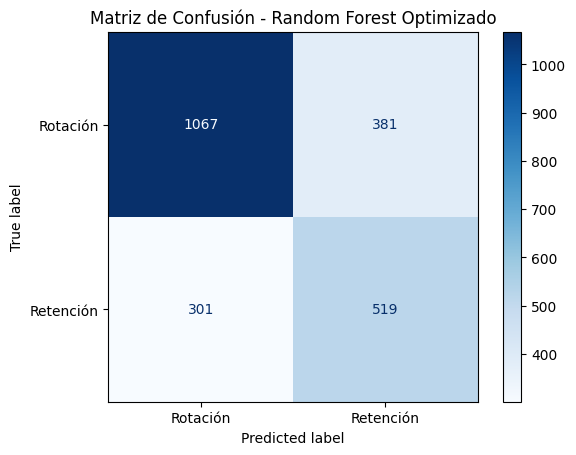

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Realizamos las predicciones finales con el modelo optimizado
y_pred_final = best_rf_model.predict(X_test)

# 2. Informe de clasificación
print("========================================================")
print("INFORME DE CLASIFICACIÓN FINAL (MODELO OPTIMIZADO)")
print("========================================================")
print(classification_report(y_test, y_pred_final, target_names=['0: Rotación', '1: Retención']))

# 3. Matriz de Confusión Visual
print("\nMATRIZ DE CONFUSIÓN FINAL:")
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rotación', 'Retención'])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión - Random Forest Optimizado")
plt.show()

## 7. Análisis de Overfitting: ¿El modelo generaliza bien?

El **Overfitting** ocurre cuando un modelo es "demasiado complejo" y memoriza el ruido de los datos de entrenamiento en lugar de aprender los patrones reales. Para verificar si nuestro Random Forest optimizado generaliza bien ante datos nuevos, comparamos su rendimiento en el conjunto de **Entrenamiento (Train)** frente al de **Prueba (Test)**.

**Criterios de evaluación:**
* **Generalización óptima:** El rendimiento en Train y Test es similar (brecha pequeña).
* **Overfitting detectado:** El rendimiento en Train es muy alto (cerca de 1.0) y en Test es significativamente bajo.
* **Robustez:** La consistencia en los resultados de la validación cruzada ($k=5$) previa ya nos sugería una alta estabilidad.

In [11]:
# 1. Calculamos las probabilidades para Train y Test
probs_train = best_rf_model.predict_proba(X_train)[:, 1]
probs_test = best_rf_model.predict_proba(X_test)[:, 1]

# 2. Calculamos el AUC-ROC en ambos
auc_train = roc_auc_score(y_train, probs_train)
auc_test = roc_auc_score(y_test, probs_test)

# 3. Mostramos resultados
print(f"AUC-ROC en Entrenamiento (Train): {auc_train:.4f}")
print(f"AUC-ROC en Prueba (Test):        {auc_test:.4f}")
print(f"Brecha (Gap):                    {abs(auc_train - auc_test):.4f}")

if abs(auc_train - auc_test) < 0.10:
    print("\nCONCLUSIÓN: El modelo GENERALIZA BIEN. La diferencia es pequeña.")
else:
    print("\nCONCLUSIÓN: Existe riesgo de OVERFITTING. La diferencia es elevada.")

AUC-ROC en Entrenamiento (Train): 0.7694
AUC-ROC en Prueba (Test):        0.7516
Brecha (Gap):                    0.0178

CONCLUSIÓN: El modelo GENERALIZA BIEN. La diferencia es pequeña.


Tras comparar el rendimiento en los conjuntos de Entrenamiento y Prueba, validamos que el modelo **Random Forest Optimizado** presenta un ajuste excelente (Good Fit):

* **Resultados Obtenidos:** El AUC-ROC de entrenamiento (0.7694) frente al de prueba (0.7516) arroja una brecha de solo **0.0178**.
* **Interpretación:** Una diferencia menor a 0.10 indica que el modelo no ha caído en el sobreajuste (*overfitting*). El modelo ha aprendido reglas generales sobre la rotación que son aplicables a nuevos egresados, y no se ha limitado a memorizar los casos particulares de la muestra de entrenamiento.
* **Éxito del Tuning:** La decisión de limitar la profundidad de los árboles (`max_depth=10`) ha sido clave para mantener esta estabilidad, sacrificando un poco de precisión en el entrenamiento a cambio de una fiabilidad mucho mayor en el mundo real.

**Dictamen Final:** El modelo es robusto, estable y está listo para ser utilizado como herramienta de apoyo en la toma de decisiones para mejorar la retención del talento joven.

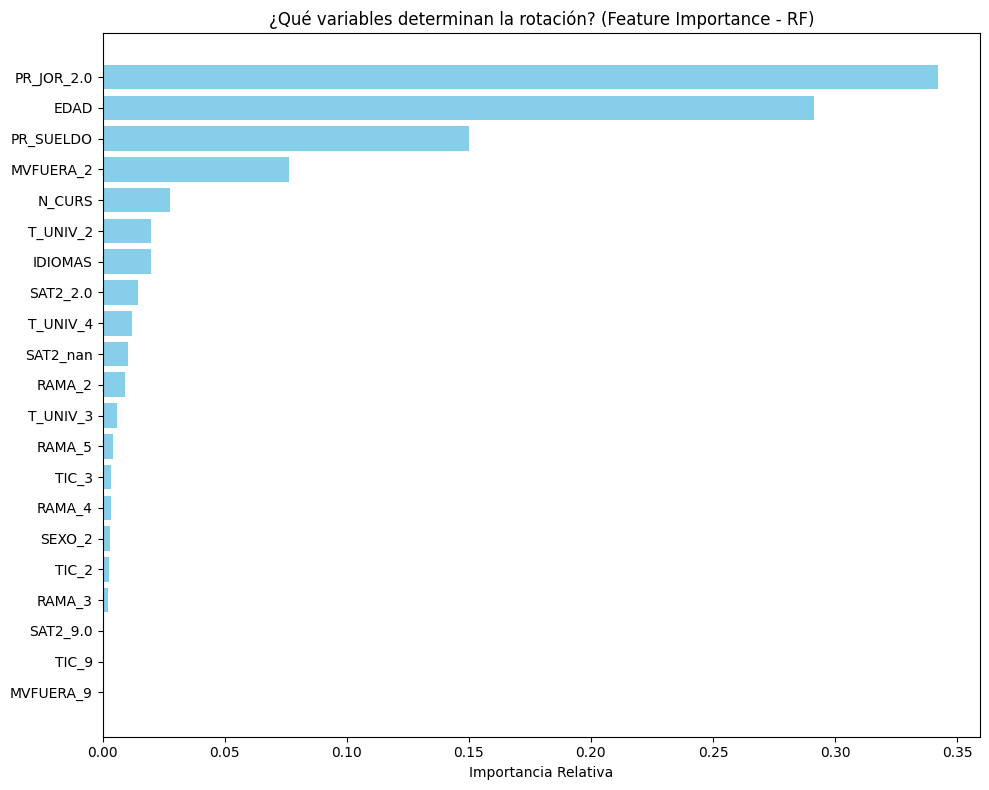

In [12]:
# 1. Extraemos las importancias del modelo y los nombres de las columnas
importancias = best_rf_model.named_steps['modelo'].feature_importances_
# Obtenemos los nombres de las columnas tras el preprocesado
nombres_columnas = (
    list(best_rf_model.named_steps['preprocesador'].transformers_[0][1].get_feature_names_out()) + # Categorical
    vars_num_ord # Numerical/Ordinal
)

# 2. Creamos un DataFrame para graficar
df_importancia = pd.DataFrame({'Variable': nombres_columnas, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=True)

# 3. Gráfico
plt.figure(figsize=(10, 8))
plt.barh(df_importancia['Variable'], df_importancia['Importancia'], color='skyblue')
plt.title('¿Qué variables determinan la rotación? (Feature Importance - RF)')
plt.xlabel('Importancia Relativa')
plt.tight_layout()
plt.show()